In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
from matplotlib import pyplot as plt
from src.data_format import format_output
from src.data import DATA_OUT_PROC, DATA_FIGURE, DATA_IN_JSONS, DATA_LABELLED
from src.accuracy import *
from src.utils import *
from src.impact_def import IMPACT_SUBTYPES_MERGED
from src.utils import MODEL_NAMES_MAP
from src.sanity_checks import flag_remove_cat


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Sensitivity analysis

In [2]:
#parameters & constants
split_lowest = False
DEF_CRS_EPSG = "EPSG:4326"
drop_appeals = [
    "MDRCO023",
    "MDRGW003",
    "MDRHU005",
    "MDRPH021",
    "MDRRS015",
    "MDRMN017",
    "MDRGT009",
    "MDRPG008",
    "MDREC019",
    "MDRTN010",
    "MDRCR012",
    "MDRGE019",]

In [3]:
#load once labelled data
res_savename_lab = "post_processed_labelled_reports_impacts_all_v111025"
split_lowest = False
suffix = "_geo_split_lowest" if split_lowest else "_geo"
suffix3 = suffix + "_v221225"
labelled_df = gpd.read_file(DATA_OUT_PROC / (res_savename_lab+suffix3+".gpkg"))

keep_appeals = [appeal for appeal in labelled_df["appealCode"].unique() if appeal not in drop_appeals]
labelled_df = labelled_df[labelled_df["appealCode"].isin(keep_appeals)]

In [4]:
#load extracted and matched data

sims = ["fixed_impact_desc", "fixed_impact_desc2", "fixed_impact_desc3"]
models = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile", "openai_gpt-oss-20b"]
rep_sims_names = {"sim1":f"post_processed_labelled_reports_fixed_impact_desc_meta-llama_llama-4-scout-17b-16e-instruct_v271025{suffix}_v221225",
                  "sim2":f"post_processed_labelled_reports_fixed_impact_desc2_meta-llama_llama-4-scout-17b-16e-instruct_v271025{suffix}_v221225",
                  "sim3":f"post_processed_labelled_reports_fixed_impact_desc3_meta-llama_llama-4-scout-17b-16e-instruct_v271025{suffix}_v221225"}

mod_sims_names = {models[0]:f"post_processed_labelled_reports_fixed_impact_desc_{models[0]}_v271025{suffix}_v221225",
                  models[1]:f"post_processed_labelled_reports_{models[1]}_v271125{suffix}_v221225",
                  models[2]:f"post_processed_labelled_reports_{models[2]}_v271125{suffix}_v221225",
                  models[3]:f"post_processed_labelled_reports_{models[3]}_v271125{suffix}_v221225"}

filename_match = "matched_data_ws6qt-ws5ql-geo-valuepre-strict-nans_"

#filtering  and processing params
value_error_th = 0.1
sim_th = 0.5
filter_flags = ["flag_unit_nonstd", "flag_remove_cat"]
remove_cats = ["DREF Allocation", "Targeted People", "Assisted People", "Other Human Impacts", "Other Infrastructural Impacts", "Other Agricultural Impacts", "Other Service Access Impacts"]
nboots = 5000
#read data
filenames = mod_sims_names
df_list = []
for key, fn in filenames.items():
    extracted_df = gpd.read_file(DATA_OUT_PROC / (fn+".gpkg"))
    matched_df = gpd.read_feather(DATA_OUT_PROC / (filename_match+fn+".feather"))
    keep_appeals = [appeal for appeal in extracted_df["appealCode"].unique() if appeal not in drop_appeals]
    #some processing
    extracted_df = extracted_df[extracted_df["appealCode"].isin(keep_appeals)]
    matched_df = matched_df[matched_df["appealCode"].isin(keep_appeals)]
    matched_df["impactValue_error"] = matched_df["impactValue_error"].replace([np.inf], np.nan)
    matched_df["impactValue_sim"] = matched_df.apply(lambda x: 1-max_value_diff(x["impactValue"], x["impactValue_matched"]).clip(0,1), axis=1)

    extracted_df["flag_remove_cat"] = extracted_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
    labelled_df["flag_remove_cat"] = labelled_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)
    matched_df["flag_remove_cat"] = matched_df.apply(flag_remove_cat, remove_cats=remove_cats, axis=1)

    extracted_df_filter = filter_by_flags(extracted_df, flag_filters=filter_flags)
    labelled_df_filter = filter_by_flags(labelled_df, flag_filters=filter_flags)
    matched_df_filter1 = filter_by_flags(matched_df, flag_filters=filter_flags)
    matched_df_filter2 = filter_matches(matched_df_filter1, value_error_th=value_error_th, sim_th=sim_th)
    coverage_df_match = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key=None)
    coverage_df_match_appeal = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="appealCode").reset_index(drop=False, names=["appealCode"])
    coverage_df_match_subtype = make_coverage_accuracy_df(extracted_df_filter, labelled_df_filter, matched_df_filter2, group_key="impactSubtype", group_keys=IMPACT_SUBTYPES_MERGED).reset_index(drop=False, names=["impactSubtype"])

    for qq in ["quanti", "quali"]:
        labelled_dfq = labelled_df_filter[labelled_df_filter["quanti"]==qq]
        extracted_dfq = extracted_df_filter[extracted_df_filter["quanti"]==qq]
        matched_df_filterq = matched_df_filter2[matched_df_filter2["quanti"]==qq]
        n_ext = len(extracted_dfq)
        n_lab = len(labelled_dfq)
        tps = true_positives(matched_df_filterq)
        fps = false_positives(n_ext, tps)
        fns = false_negatives(n_lab, tps)
        precisions = precision_bt(tps, fps)
        recalls = recall_bt(tps, fns)
        f1s = f1_bt(tps, fps, fns)
        bs_metric_dict = bootstrap_f1(tps, fps, fns, n_boot=nboots)
        dict_res = {
                "key" : key,
                "quanti" : qq,
                "tps": tps,
                "f1": f1s,
                "precision": precisions,
                "recall": recalls,
                "f1_low_err": f1s - bs_metric_dict["f1_score"][0],
                "f1_high_err": bs_metric_dict["f1_score"][1] - f1s,
                "precision_low_err": precisions - bs_metric_dict["precision"][0],
                "precision_high_err": bs_metric_dict["precision"][1] - precisions,
                "recall_low_err": recalls - bs_metric_dict["recall"][0],
                "recall_high_err": bs_metric_dict["recall"][1] - recalls

        }
        df_list.append(pd.DataFrame(dict_res, index=[0]))

f1_bs_all = pd.concat(df_list)



In [5]:
#prepare data for plots
f1_bs_all["quanti"].replace("quanti", "Quantitative total", inplace=True)
f1_bs_all["quanti"].replace("quali", "Qualitative total", inplace=True)


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_43552/945045040.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  f1_bs_all["quanti"].replace("quanti", "Quantitative total", inplace=True)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_43552/945045040.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we 

In [6]:
metrics = ["f1", "precision", "recall"]
for met in metrics:
    f1_bs_all.loc[:,met+"_low"] = f1_bs_all[met] - f1_bs_all[met+"_low_err"]
    f1_bs_all.loc[:,met+"_high"] = f1_bs_all[met+"_high_err"] + f1_bs_all[met]

mmax = f1_bs_all.groupby("quanti").max()[metrics]#[[met + "_high" for met in metrics]]#[metrics]
mmin = f1_bs_all.groupby("quanti").min()[metrics]#[[met + "_low" for met in metrics]]
dmax = mmax.values - mmin.values

In [7]:
metrics = ["f1"]

f1_plot = f1_bs_all.melt(id_vars=["quanti", "key"])
f1_plot_met = f1_plot[f1_plot["variable"].isin(metrics)]

In [8]:
f1_plot_met

,quanti,key,variable,value
8,Quantitative total,meta-llama_llama-4-scout-17b-16e-instruct,f1,0.424116
9,Qualitative total,meta-llama_llama-4-scout-17b-16e-instruct,f1,0.504732
10,Quantitative total,llama-3.1-8b-instant,f1,0.374291
11,Qualitative total,llama-3.1-8b-instant,f1,0.394937
12,Quantitative total,llama-3.3-70b-versatile,f1,0.546087
13,Qualitative total,llama-3.3-70b-versatile,f1,0.526718
14,Quantitative total,openai_gpt-oss-20b,f1,0.478702
15,Qualitative total,openai_gpt-oss-20b,f1,0.390909


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_43552/2815577920.py:4: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(data=f1_plot_met, x="value", y="quanti", hue="variable", errorbar=lambda x: (x.min(), x.max()), ax=axes, palette=colors)


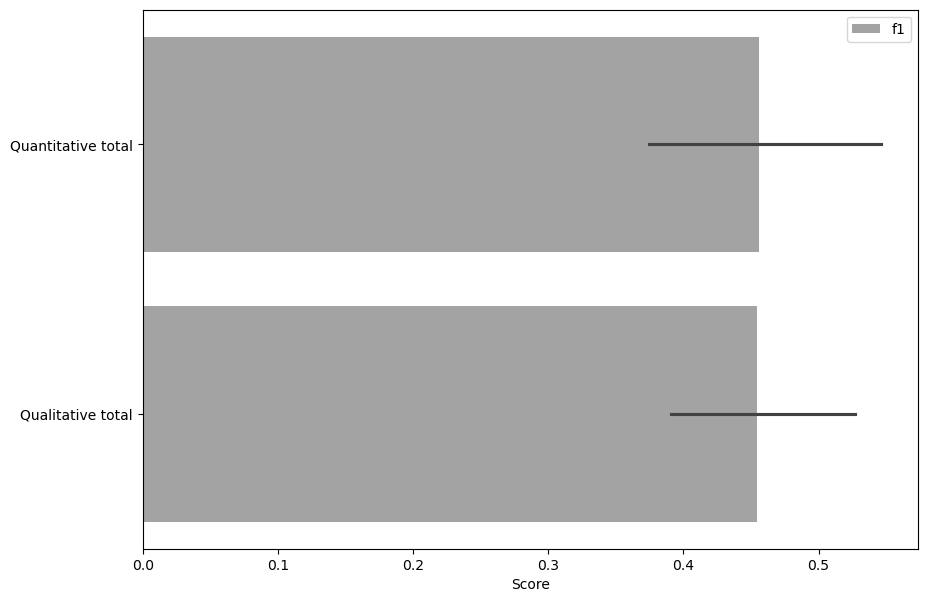

In [9]:
#plot sensitivity by repetition
fig, axes = plt.subplots(1, 1, figsize=(10, 7), sharey=False, sharex=False)
colors = ["#a3a3a3", "#6c6236"]
sns.barplot(data=f1_plot_met, x="value", y="quanti", hue="variable", errorbar=lambda x: (x.min(), x.max()), ax=axes, palette=colors)
axes.set_ylabel("")
axes.set_xlabel("Score")
legend = axes.get_legend()
legend.set_title("")
#fig.savefig(DATA_FIGURE / f"sens_analysis_diff_simulations.png", bbox_inches="tight", dpi=300)

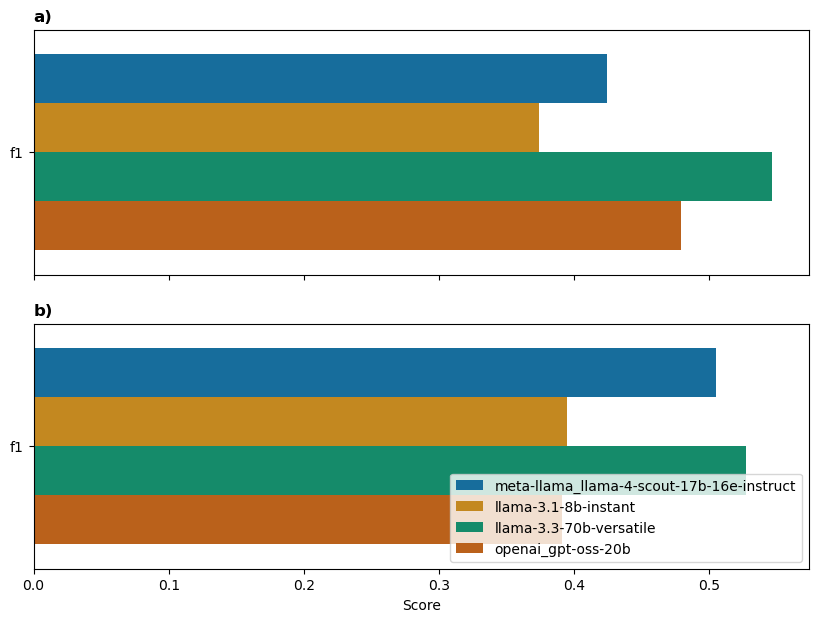

In [10]:
#plot sensitivity by model
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharey=True, sharex=True)
cols = ["Quantitative total", "Qualitative total"]
labels=["a)", "b)"]
for i, col in enumerate(cols):
    sns.barplot(data=f1_plot_met[f1_plot_met["quanti"] == col], x="value", y="variable", hue="key", ax=axes[i], palette="colorblind")# palette=colors
    axes[i].set_ylabel("")
    axes[i].set_xlabel("Score")
    axes[i].set_title(labels[i], fontweight="bold", loc="left")
axes[0].get_legend().remove()
legend = axes[1].get_legend()
legend.set_title("")
legend.set_loc("lower right")
fig.savefig(DATA_FIGURE / f"sens_analysis_diff_models.png", bbox_inches="tight", dpi=300)

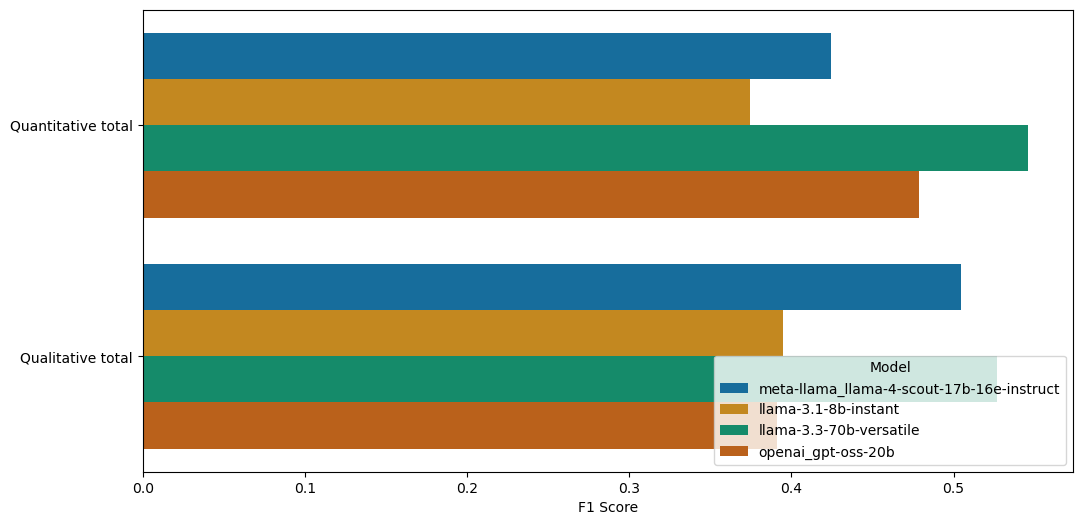

In [11]:
#plot sensitivity by model
fig, axes = plt.subplots(1, 1, figsize=(12, 6), sharey=True, sharex=True)
cols = ["Quantitative total", "Qualitative total"]
labels=["a)", "b)"]

sns.barplot(data=f1_plot_met, x="value", y="quanti", hue="key", ax=axes, palette="colorblind")# palette=colors
axes.set_ylabel("")
axes.set_xlabel("F1 Score")

legend = axes.get_legend()
legend.set_title("Model")
legend.set_loc("lower right")
fig.savefig(DATA_FIGURE / f"F1_sens_analysis_diff_models.png", bbox_inches="tight", dpi=300)

## Sensitivity to external variables

In [ ]:
## add other variables useful for analysis
#report length
extracted_df["reportSize"] = extracted_df["nathaz_text"].apply(len)

#report type
file_path = DATA_IN_JSONS / "preproc_filtered_report_types_nat_hazards_bugfix_v250925.csv"#'all_ifrc_reports_info_processed_extended_format_nb_std_units.json' "nathaz_ifrc_reports_info_processed.json"
ifrc_reports_df = pd.read_csv(file_path)

keys = labelled_df[['appealCode', 'reportDate']].drop_duplicates()
labelled_reports_raw = ifrc_reports_df.merge(keys, on=['appealCode', 'reportDate'], how='inner')


#add vars to dfs
extracted_df = extracted_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])
labelled_df = labelled_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])
matched_df = matched_df.merge(labelled_reports_raw[["appealCode", "reportDate", "appealType"]], how="left", on=["appealCode", "reportDate"])


In [ ]:
from src.labelling_helpers import filter_reports
ifrc_reports_df_filtered = filter_reports(ifrc_reports_df, take_latest=True)


/Users/lseverino/Documents/PhD/Projects/Como/como_project4/src/labelling_helpers.py:39: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: sort_appeal_type(x))
/Users/lseverino/Documents/PhD/Projects/Como/como_project4/src/labelling_helpers.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sort_values(date_field, ascending=False).head(1))


/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_3312/3991066840.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of t

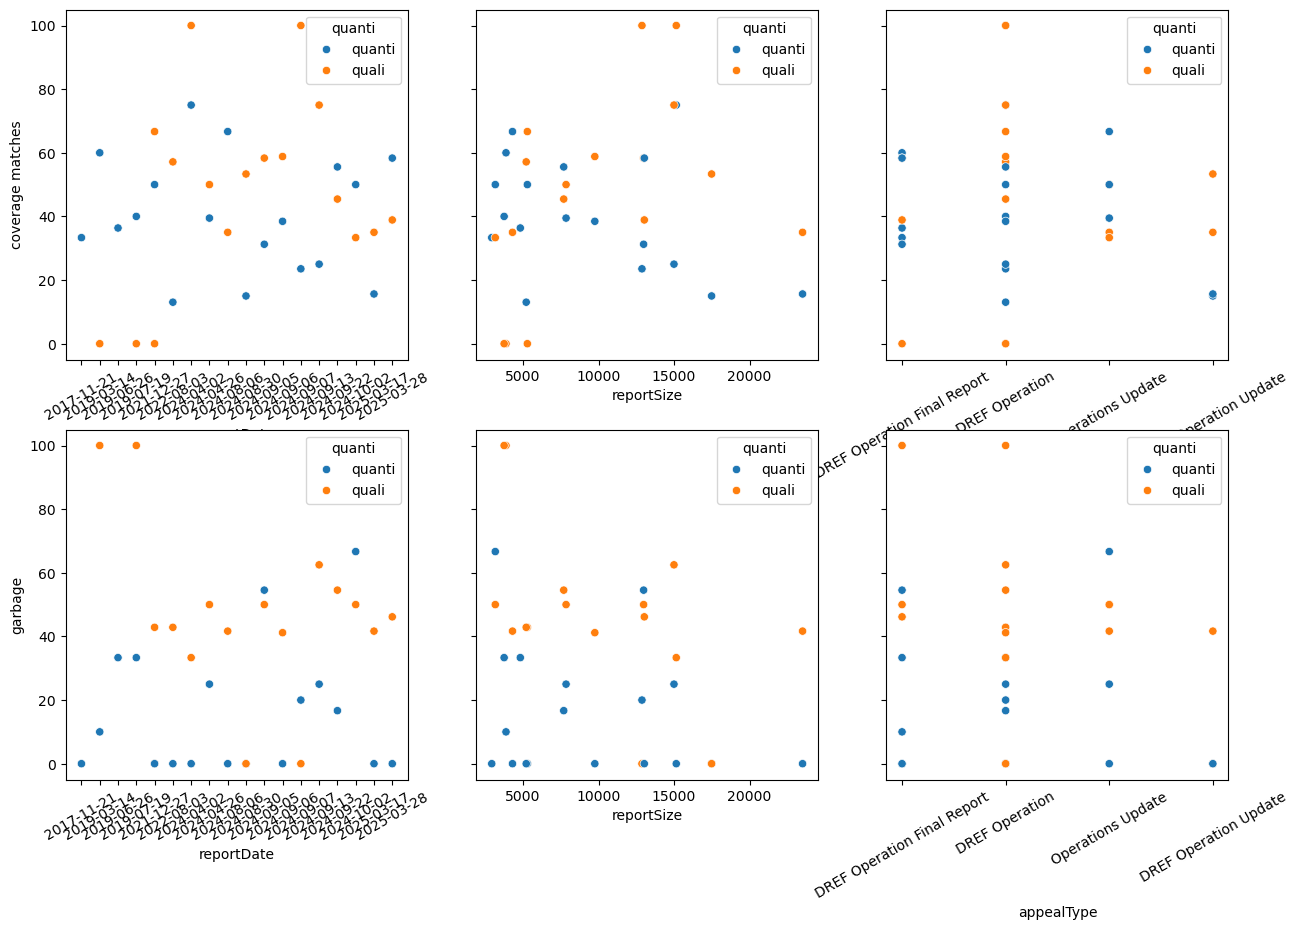

In [12]:
#inspect sensitivity to other variables e.g. date report type, lentgth
external_vars = ["reportDate", "reportSize", "appealType"]
fig, axes = plt.subplots(2, len(external_vars), figsize=(15, 10), sharey=True, sharex=False)
coverage_df_match_appeal = coverage_df_match_appeal.sort_values("reportDate")
for i, var in enumerate(external_vars):
    sns.scatterplot(coverage_df_match_appeal, x=var, y="coverage matches", hue="quanti", ax=axes[0, i])
    sns.scatterplot(coverage_df_match_appeal, x=var, y="garbage", hue="quanti", ax=axes[1, i])
    if var in ["reportDate", "appealType"]:
        axes[0, i].set_xticklabels(axes[0, i].get_xticklabels(), rotation=30)
        axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=30)
fig.savefig(DATA_FIGURE / f"coverage_matches_by_{yvar}_external_vars_valerr_th-{value_error_th}_sim_th-{sim_th}_{filename_match}.png", bbox_inches="tight", dpi=300)

In [150]:
#inspect sensitivity to thresholds

value_error_ths = np.arange(0.01, 0.3, 0.01)
sim_ths = np.arange(0.2, 1, 0.1)
vth_scores = []
for vth in value_error_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=vth, sim_th=0.6)
    make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None)
    vth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])

sth_scores = []
for sth in sim_ths:
    matched_df_filter = filter_matches(matched_df, value_error_th=0.1, sim_th=sth)
    sth_scores.append(make_coverage_accuracy_df(extracted_df, labelled_df, matched_df_filter, group_key=None).set_index("quanti",drop=True)[["coverage matches", "garbage"]])


Overall average quanti: 176 extracted, 336 labelled, 96 correct matches, 80 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 96 correct matches, 80 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 97 correct matches, 79 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 97 correct matches, 79 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 98 correct matches, 78 garbage matches
Overall average quali: 146 extracted, 174 labelled, 65 correct matches, 81 garbage matches
Overall average quanti: 176 extracted, 336 labelled, 98 correct matches, 78 garbage m

<Axes: >

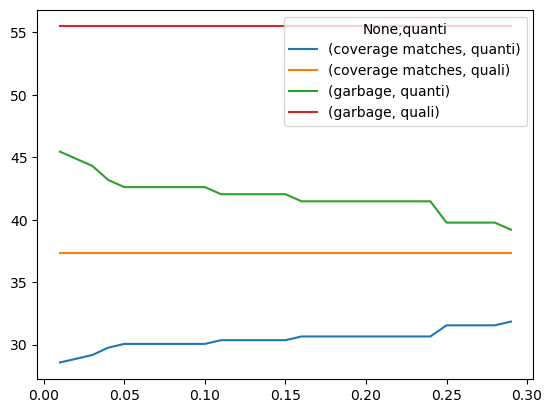

In [151]:
sensi_vth_df = pd.concat(vth_scores, keys=value_error_ths).unstack()
sensi_vth_df.plot()

<Axes: >

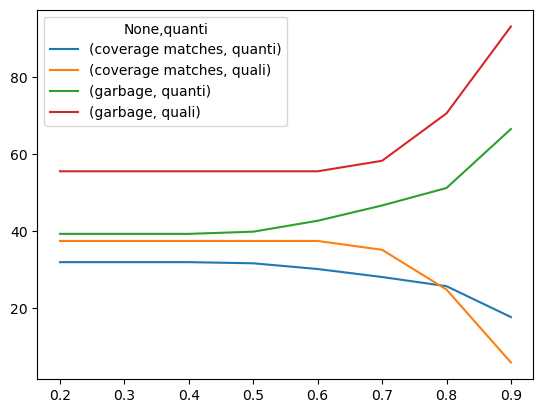

In [152]:
sensi_sth_df = pd.concat(sth_scores, keys=sim_ths).unstack()
sensi_sth_df.plot()

In [4]:
## Compare coverage by categories between labelled and extracted for all impacts

keys = ["meta-llama_llama-4-scout-17b-16e-instruct", "llama-3.1-8b-instant", "llama-3.3-70b-versatile"]
key = keys[0]
extracted_lab_name = f"merged_subtypes_post_processed_labelled_reports_fixed_impact_desc_{key}_v271025"
extracted_all_name = f"merged_subtypes_post_processed_all_appeals_unique_1-333_{key}_v281025"

extracted_lab = pd.read_csv(DATA_OUT_PROC / (extracted_lab_name+".csv"))
extracted_df_long = pd.read_csv(DATA_OUT_PROC / (extracted_all_name+".csv"))


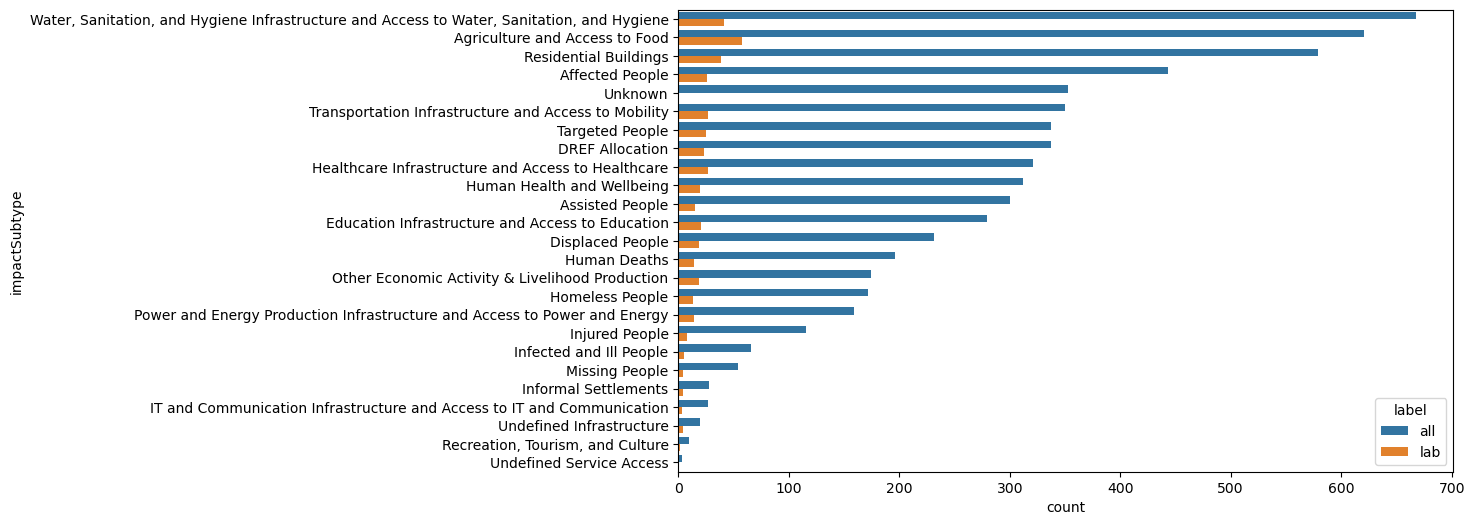

In [5]:
#merge dfs
extracted_lab["label"] ="lab"
extracted_df_long["label"] = "all"
extracted_df_all = pd.concat([extracted_lab, extracted_df_long])
plot_df = extracted_df_all.value_counts(["impactSubtype", "label"]).reset_index()
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
sns.barplot(data=plot_df, x="count", y="impactSubtype", hue="label", axes=ax)
fig.savefig(DATA_FIGURE / f"impactSubtype_distr_lab_vs_333_{extracted_lab_name}.png", bbox_inches="tight", dpi=300)
